#Spaceship Titanic

## Bienvenidos a la práctica de EDA.

En este notebook se nos presenta un "toy dataset" para poner en práctica lo que hemos aprendido hasta ahora sobre cómo realizar un buen EDA. Para la ejecución de la misma necesitaremos:
1. Un venv en local para que cada uno pueda trabajar de forma individual en las celdas que se os pida hacer algo.
2. Que abráis una cuenta en Kaggle (es gratuita). https://www.kaggle.com/  

Se nos presenta un ejercicio "Spaceship Titanic". Kaggle (www.kaggle.com) es una plataforma donde se reúnen miles de personas con interés o experiencia en
el análisis de datos, ofreciendo la posibilidad de competir para resolver requisitos estratégicos que presentan
los grandes datos de las empresas a cambio de dinero. Empresas y compa˜nías de todo el mundo exponen sus
problemas y sus retos en esta plataforma y la comunidad de científicos de datos compite para crear las mejores
soluciones y los mejores modelados teóricos.

En la plataforma se presenta cualquier tipo de problema que pueda encontrarse en los distintos campos del
mundo real, tales como servicios financieros, energía, tecnologías de la información, etc.
El enfoque crowdsourcing utilizado se debe a la existencia de una cantidad indefinida de posibles soluciones y
estrategias que se pueden aplicar a un problema complejo de modelado predictivo donde no es posible saber con
antelación la técnica o la estrategia que será más adecuada y más eficaz.
Fundada por el economista australiano Anthony Goldbloom, la inspiración para crear Kaggle proviene en parte
de una competición creada por Netflix entre 2006 y 2009. La empresa de alquiler de películas ofrecía un millón
de dólares al equipo que fuera capaz de mejorar la precisión de su sistema de recomendación de títulos en un
10 %.


## Objetivo

Este proyecto busca llevar a cabo un proyecto que permita demostrar las habilidades aprendidas durante el
curso. El primer requisito es que el conjunto de datos utilizado posea un número razonable de variables y
observaciones para que tengáis que ir más allá de la aplicación de un algoritmo simple de selección de variables
para la construcción de un modelo final. Y la mejor forma de aprender, es practicando.

En cuanto al problema a resolver, estamos en 2912 y se ha recibido una transmisión desde cuatro a˜nos luz
de distancia con malas noticias. La nave espacial Titanic emprendió un viaje interestelar para transportar
emigrantes de nuestro sistema solar a tres exoplanetas descubiertos recientemente que parecen habitables y
orbitan estrellas cercanas. Por desgracia, la nave espacial chocó con una anomalía escondida dentro de una nube
de polvo y casi la mitad de los pasajeros fueron transportados a una dimensión alternativa. El problema que se
presenta en esta competición es ayudar a las tripulaciones de rescate a recuperar a los pasajeros perdidos, para
lo cuál se debe predecir qué pasajeros fueron transportados por la anomalía utilizando los registros recuperados
del sistema informático da˜nado.

Con respecto al conjunto de datos, este está formado por 13000 instancias y 14 variables (incluyendo la variable
clase a predecir), las cuáles se centran en la descripción de multitud de aspectos de cada uno de los pasajeros.
En general, las variables categóricas hacen referencia al planeta de residencia, destino, etc. Por su parte, las
variables numéricas describen la edad, facturación por el servicio de habitaciones, compras, etc. Aquí tenéis en enlace a la competición: https://www.kaggle.com/competitions/spaceship-titanic

Vuestra tarea como aprendices en NTTData es predecir si los pasajeros fueron transportados a la dimensión alternativa o no. Para
comenzar a trabajar, se os facilitará una carpeta “Data” donde encontraremos los siguientes ficheros: train.csv, test.csv y
sample_submission.csv. El conjunto de datos de entrenamiento se encuentra en train.csv y consta de 8693
instancias. Por su parte, el conjunto de datos de prueba es test.csv, está formado por 4277 instancias y se
utilizará para realizar la predicción. Por último, el fichero sample_submission.csv proporciona un formato de
muestra para el envío de resultados a la plataforma Kaggle. 

Que la fuerza os acompañe!



In [ ]:
# # Instalación de libs
# %pip install pandas
# %pip install numpy 
# %pip install matplotlib
# %pip install seaborn
# %pip install -U scikit-learn
# %pip install xgboost

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, OrdinalEncoder, FunctionTransformer, KBinsDiscretizer, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns



from sklearn import set_config
set_config(transform_output = "pandas")

EDA "EXPLORATORY DATA ANALYSIS"

Tres conjuntos distintos:

- Train (entrenamiento) → Para entrenar el modelo
- Validation (validación) → Para ajustar hiperparámetros y evaluar durante el desarrollo
- Test (test final) → Para medir el rendimiento final (no se toca hasta el final)

In [ ]:
EDA_train_raw = pd.read_csv("./train.csv", sep=",") #importamos csv todo el conjunto de train sin dividir

EDA_test_data=pd.read_csv("./test.csv", sep=",") #importamos csv el conjunto de test para el test final

target_feature='Transported'

#split


#concatenamos los datos con el target en cada conjunto. 


In [ ]:
#visualizar el tamaño de cada split

In [ ]:
#visualizar las primeras filas del df

In [ ]:
#imprimir todas las variables  y el tipo que es cada una
#las numéricas
#las categóricas



In [ ]:
#listar el numero de valores NA por columna y sus porcentajes



#### IMPUTACIÓN DE VALORES NA

Imputar = rellenar valores faltantes (NaN) para poder usar el dataset en modelos (la mayoría de modelos no aceptan valores nulos)
#### 🔢 VARIABLES NUMÉRICAS
 -------------------------
 Aquí usamos la MEDIANA para rellenar los NA
 ¿Por qué mediana?
 - Es robusta a outliers (valores extremos)
 - Mejor que la media si la distribución está sesgada (muy común en datos reales)
 - Mantiene una representación más "realista" del centro de los datos

 Alternativas:
 - mean(): útil si los datos son normales (sin outliers)
 - 0 o constante: rápido pero puede distorsionar mucho
 - interpolación: útil en series temporales
 - modelos (KNN, regresión): más preciso pero más complejo


#### 🏷️ VARIABLES CATEGÓRICAS
 -------------------------
 Aquí usamos la MODA (valor más frecuente)
 ¿Por qué moda?
 - Tiene sentido porque son categorías (no puedes hacer media)
 - Mantiene la categoría más representativa

 Alternativas:
 - "Unknown" / "Missing": útil si el hecho de faltar es información relevante
 - imputación por grupo (ej: por PassengerId, grupo familiar, etc.)
 - modelos (ej: predecir categoría): más complejo

 ⚠️ IMPORTANTE:
 .mode() devuelve una serie → normalmente usamos el primer valor con [0]

In [ ]:
#imputation NA values in numeric columns and categorical
#numeric -> median
#cat -> mode




EDA: Visualizaciones y plots

In [ ]:
#plotear distribución atendiendo a la clase final



In [ ]:
# Plot planet related histograms 
# Crear un espacio para dos gráficos uno al lado del otro
fig, axes = plt.subplots(2, 2, figsize=(5, 5))

# Primer gráfico: 


# Segundo gráfico


# Tercer gráfico: 



# Cuarto gráfico


# Ajustar el diseño para evitar solapamiento
plt.tight_layout()


#guardar el grafico 
plt.savefig('distribuciones simples.png')

# Mostrar el gráfico
plt.show()

ANÁLISIS

In [ ]:
# Plot planet related histograms vs class
#Quiero que ploteeis la distribución atendiendo a la clase de las variables [homeplanet, destination, vip, cryosleep], cada uno en un plot. En cada plot tipo histograma, deberá salir la distribución 
#y también la clase

# Crear un espacio para dos gráficos uno al lado del otro
fig, axes = plt.subplots(2, 2, figsize=(7, 7))

# Primer gráfico: 


# Segundo gráfico


# Primer gráfico: 


# Segundo gráfico



# Ajustar el diseño para evitar solapamiento
plt.tight_layout()


#guardar el grafico 
plt.savefig('distribucion clase.png')

# Mostrar el gráfico
plt.show()

ANÁLISIS

In [ ]:
#calculo de probabilidades 

# pista: Crear una tabla de contingencia y normalizarla PARA HomePlanet, Destination, VIP, CryoSleep


In [ ]:
#heatmap resumen. qUIERO VER EN UN MISMO PLOT, PARA CADA ORIGEN/DESTINO POSIBLE LA PROBABILIDAD DE SER O NO TRANSPORTADO

# PISTA: Crear una tabla de contingencia y normalizarla


plt.tight_layout()


plt.show()

In [ ]:
#plot de la variable cabin. Al contener mucha info la separamos primero en deck, num, side y ploteamos en histograma vs transported



# Ajustar el diseño para evitar solapamiento
plt.tight_layout()
plt.legend(fontsize='small')


# Mostrar el gráfico
plt.show()

MÁS GRAFICOS DE INTERÉS

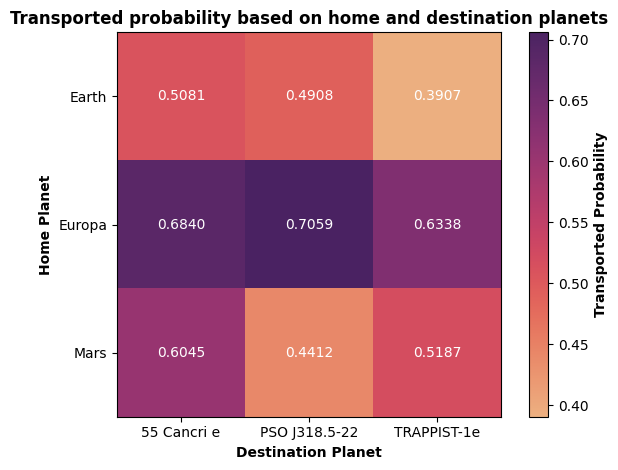

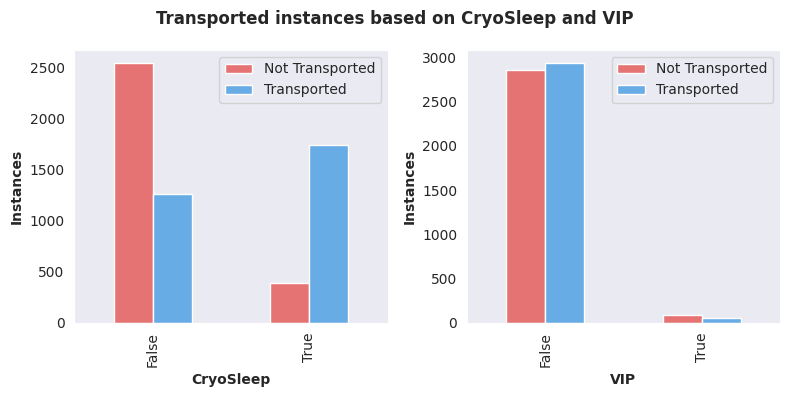

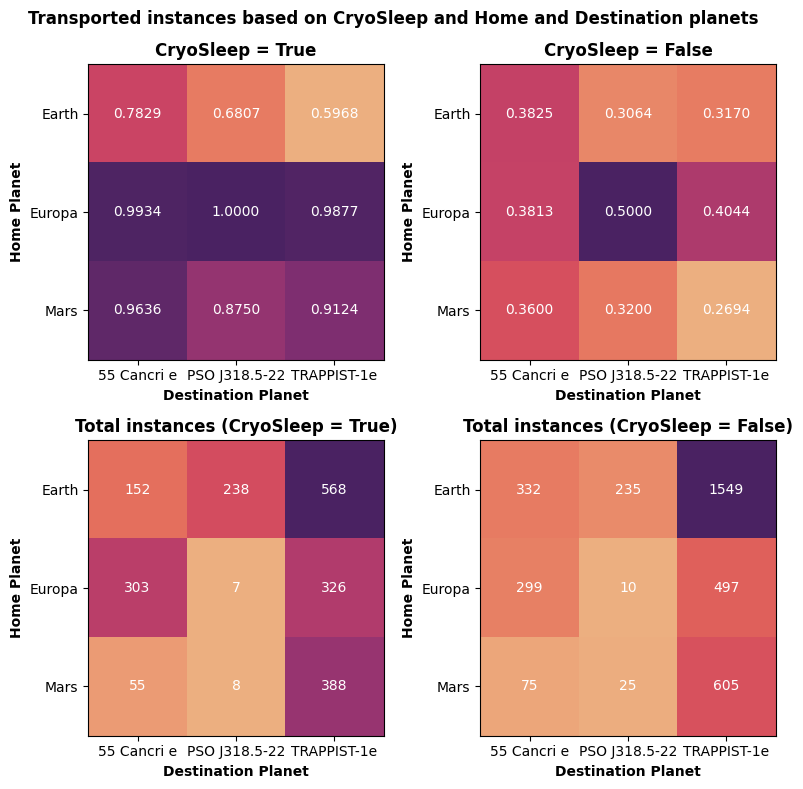

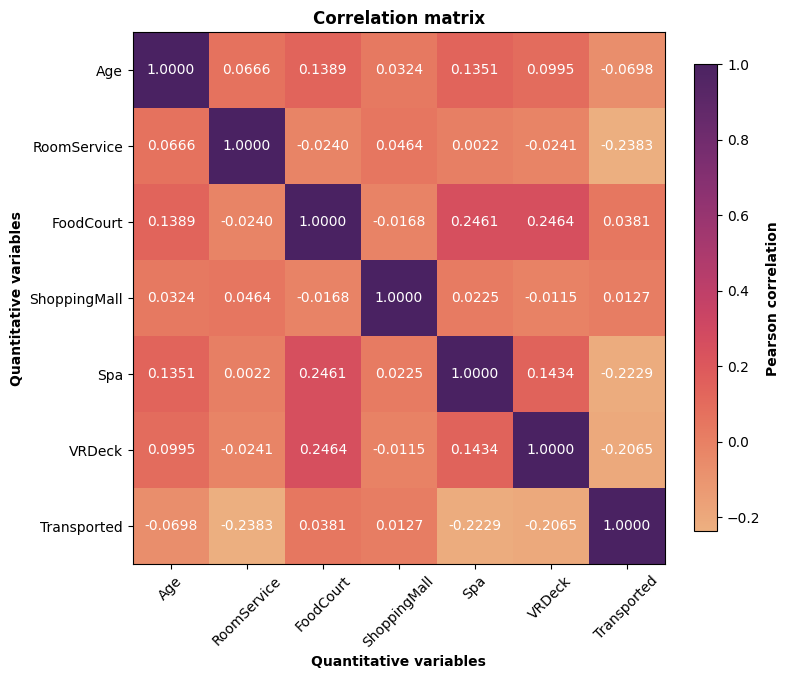

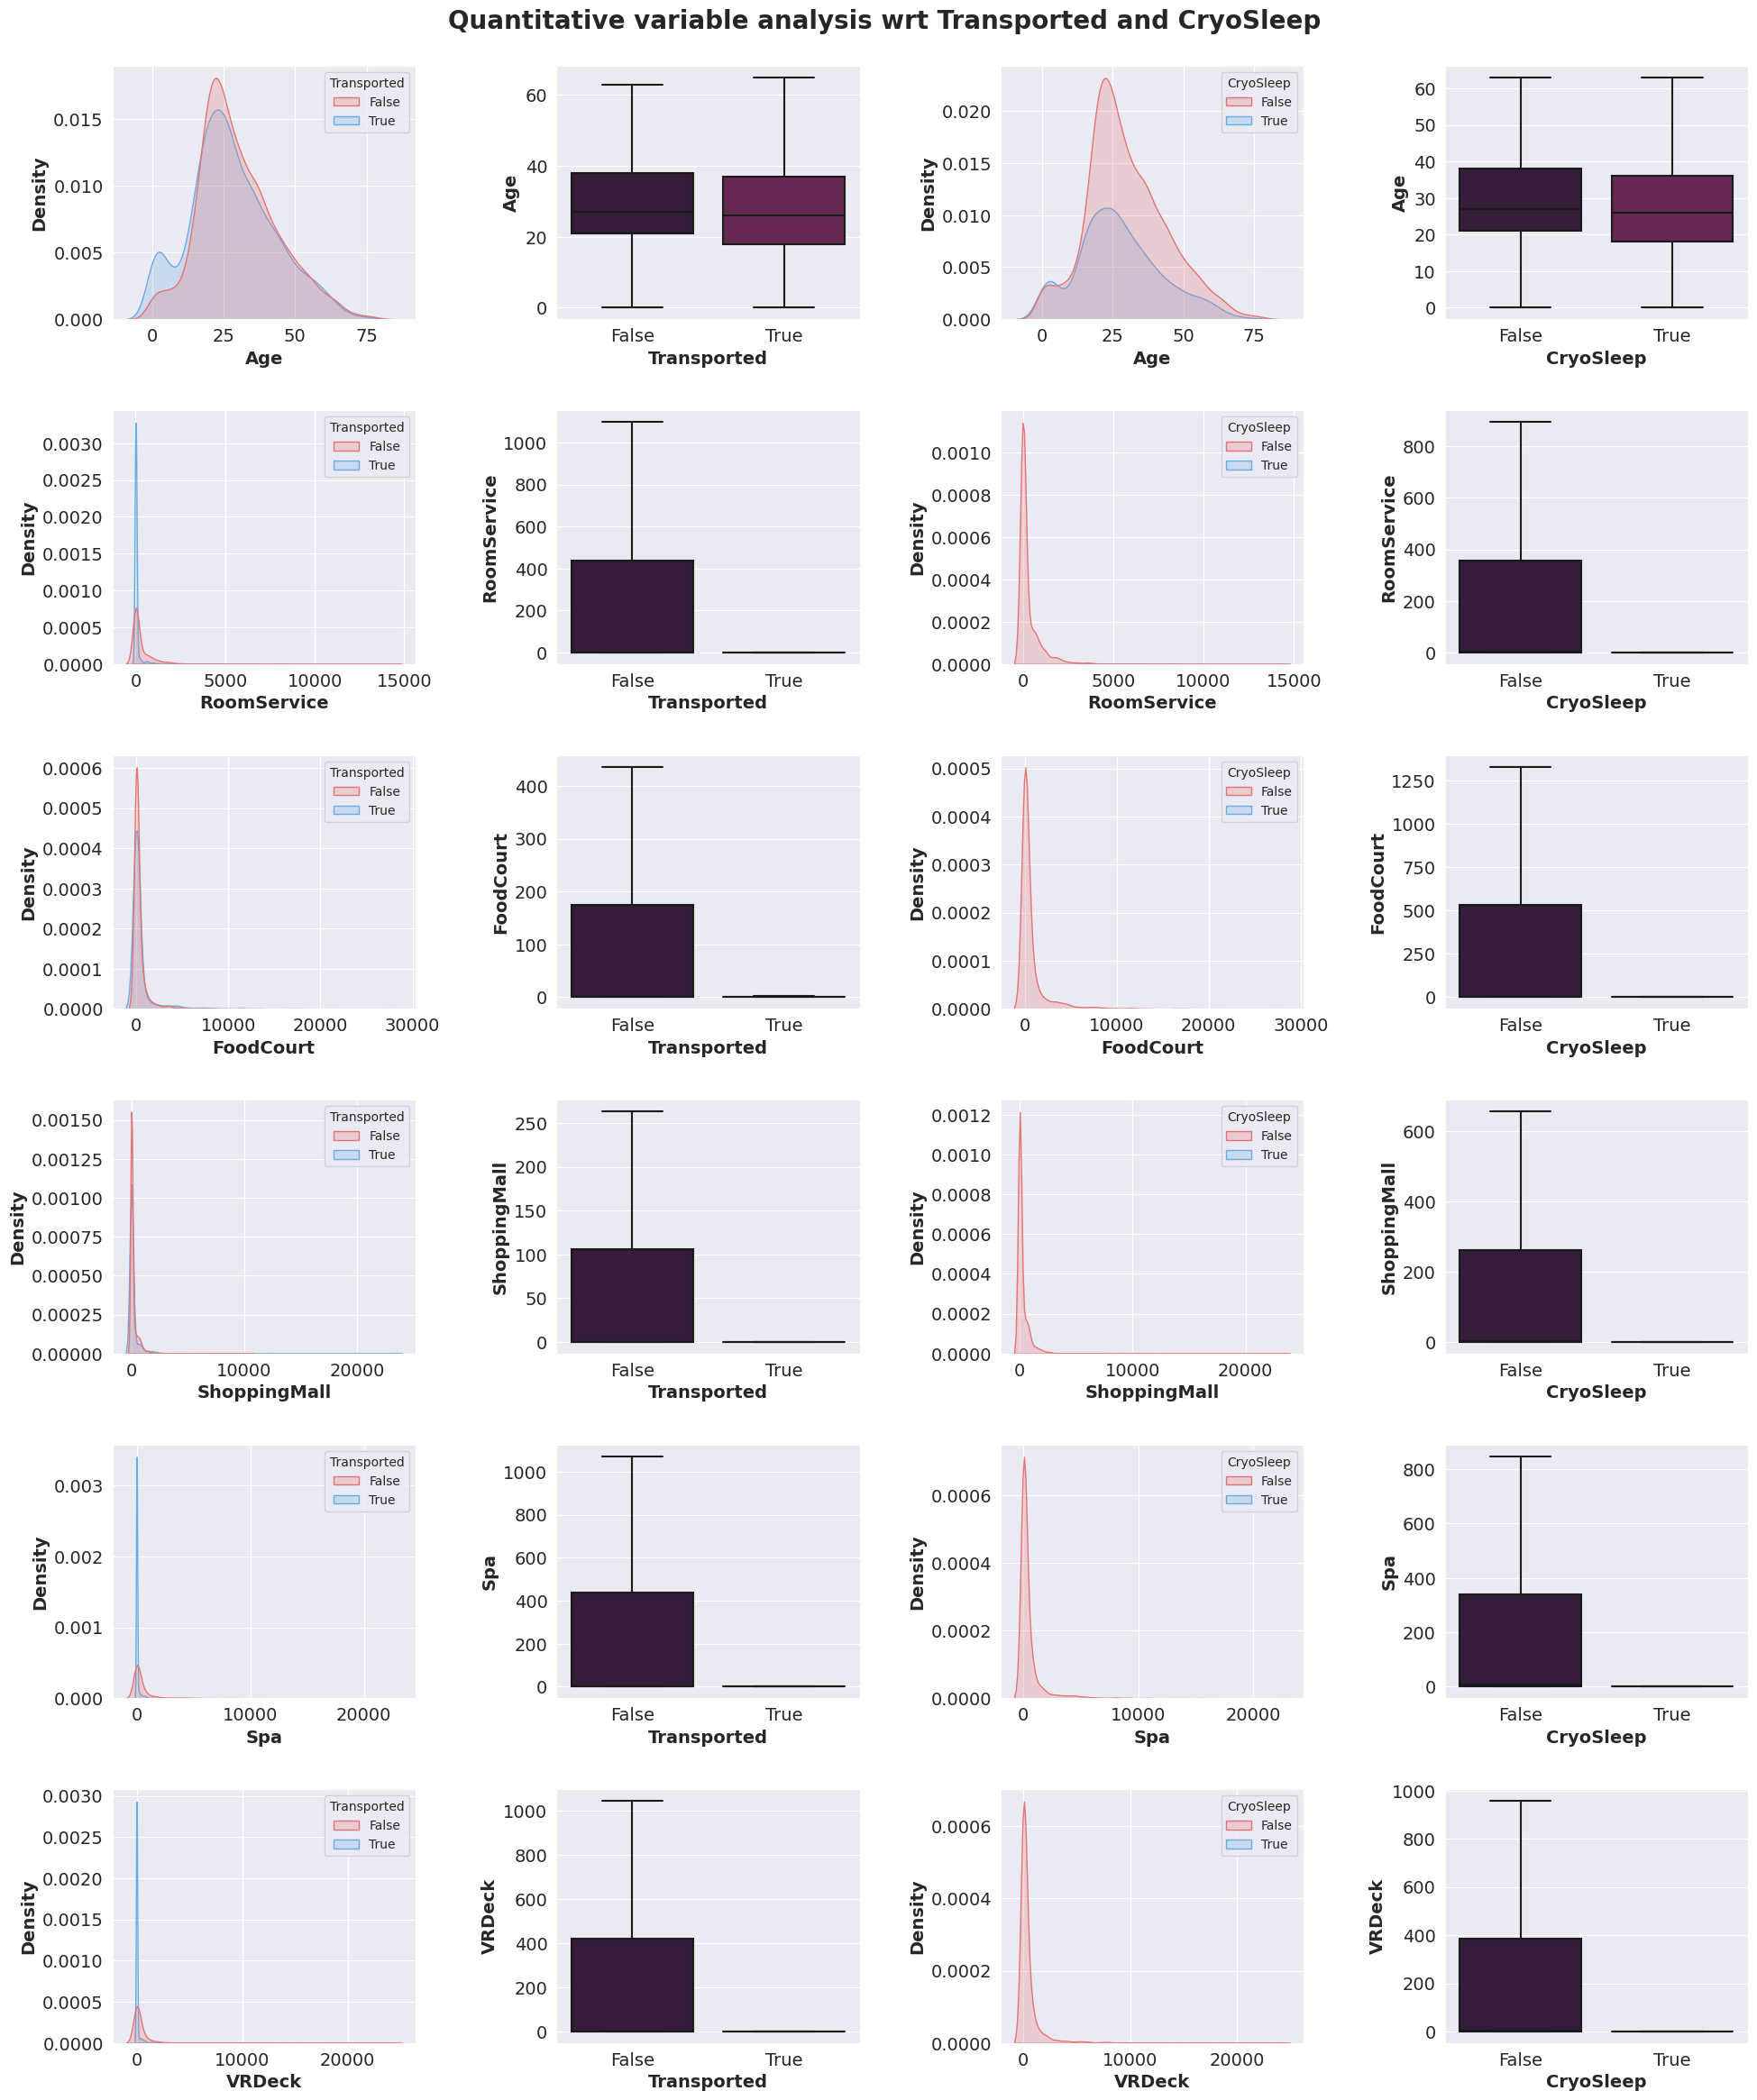

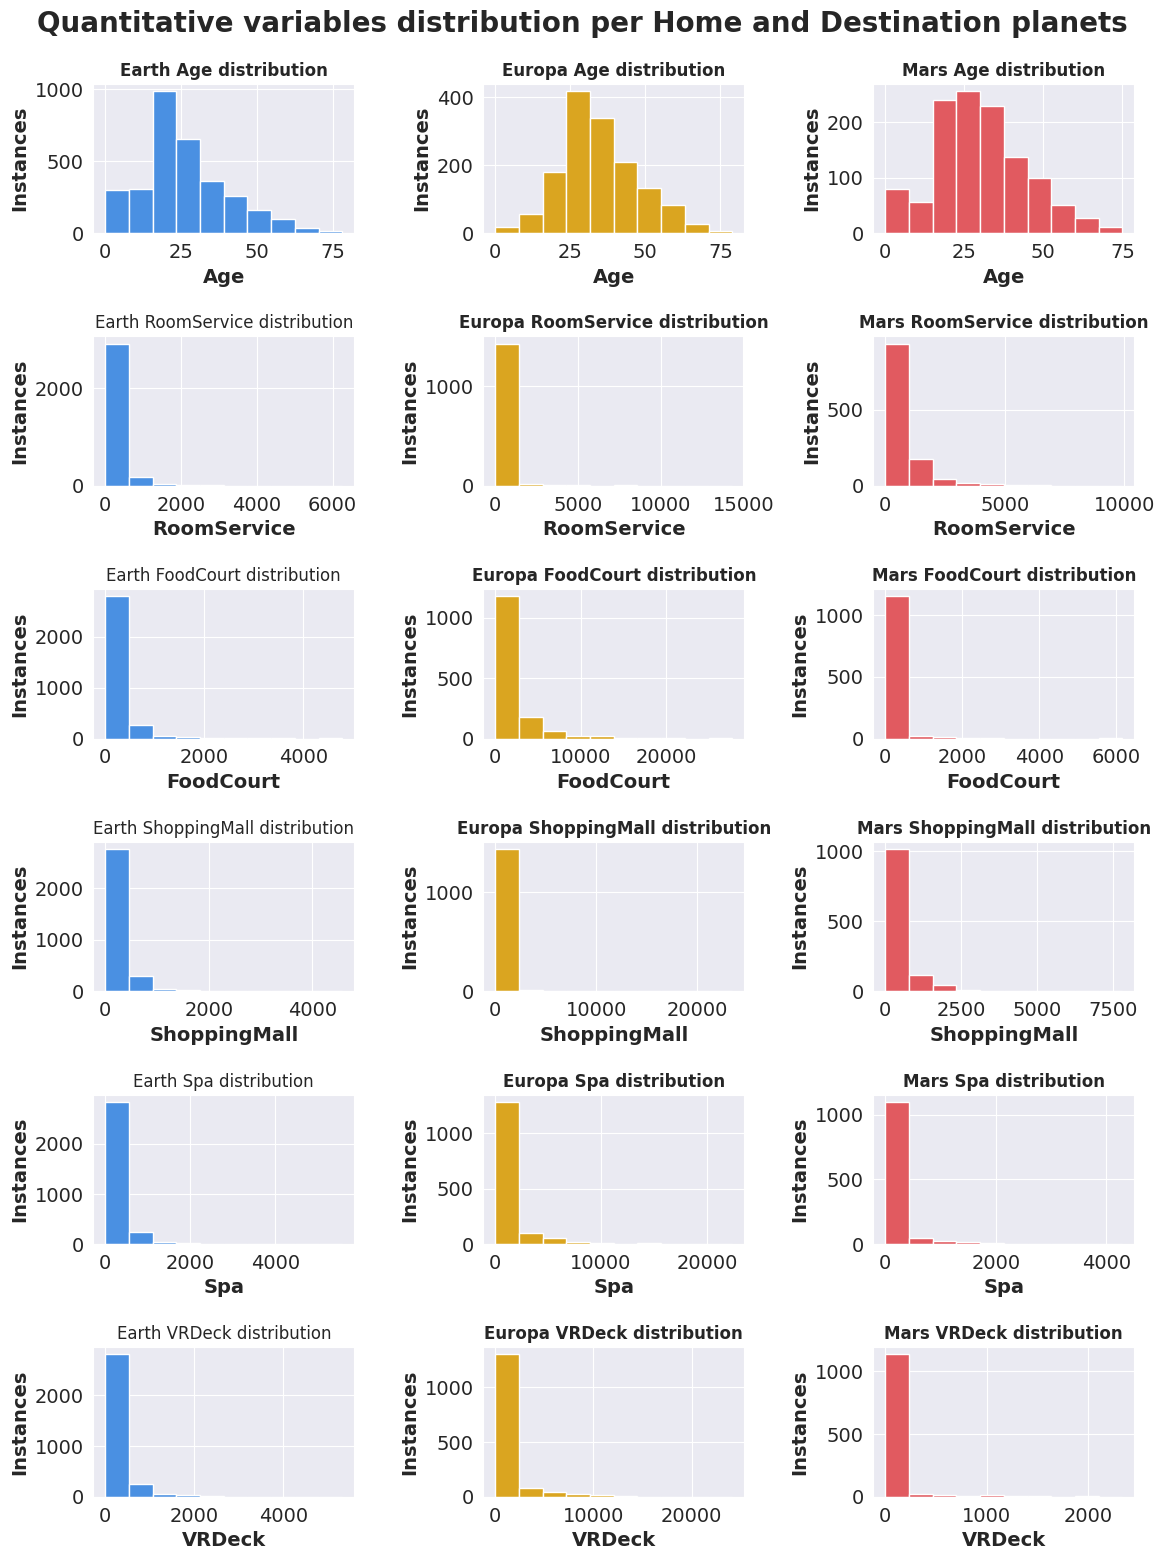

In [ ]:
#feature engineering

#procesado de la columna cabin:
deck=EDA_train_raw_imputed["Cabin"].str.split("/").str[0]
# /num
num=EDA_train_raw_imputed["Cabin"].str.split("/").str[1]
# /side
side=EDA_train_raw_imputed["Cabin"].str.split("/").str[-1]

#eliminamos la columna name, ya que al haber sustituido por la moda todos los nombres NA (unos 200), el nombre sale repetido y se ven relaciones que no eEDA_train_rawisten.
#realmente el nombre es como un ID, es una columna que de momento elimino porque no le veo utilidad


#eliminamos la columna cabin y en su lugar generamos 3 independientes con deck, num, side


#convertimos la columa "Cabin_Num a de tipo object a int"


#añadimos una columa que sume todos los gastos asociados a servicios durante el viaje


#Ahora cruzaremos Gastos con Cryo, dado que alguien que va cryo no debería contratar un servicio de Spa, entre otros. Por ello corregimos el valor de CryoSleep
EDA_train_raw_imputed['Mod_CryoSleep'] = EDA_train_raw_imputed['CryoSleep'].copy() #duplicamos la columna CryoSleep y le ponemos Mod_CryoSleep
resultado = EDA_train_raw_imputed[(EDA_train_raw_imputed['Gastos'] == 0) & (EDA_train_raw_imputed['CryoSleep']==False)]
EDA_train_raw_imputed.loc[EDA_train_raw_imputed['Gastos'] == 0, 'Mod_CryoSleep'] = True
EDA_train_raw_imputed.drop('CryoSleep',axis=1,inplace=True)

#añadimos si la persona va sola o acompañada
EDA_train_raw_imputed['Personas_Grupo'] = EDA_train_raw_imputed.PassengerId.apply(lambda x: x.split('_')).apply(lambda x: x[0])
EDA_train_raw_imputed['Acompañado'] = ((EDA_train_raw_imputed['Personas_Grupo'].value_counts() > 1).reindex(EDA_train_raw_imputed['Personas_Grupo'])).tolist()
EDA_train_raw_imputed.drop('Personas_Grupo',axis=1,inplace=True)

#eliminamos passengerID


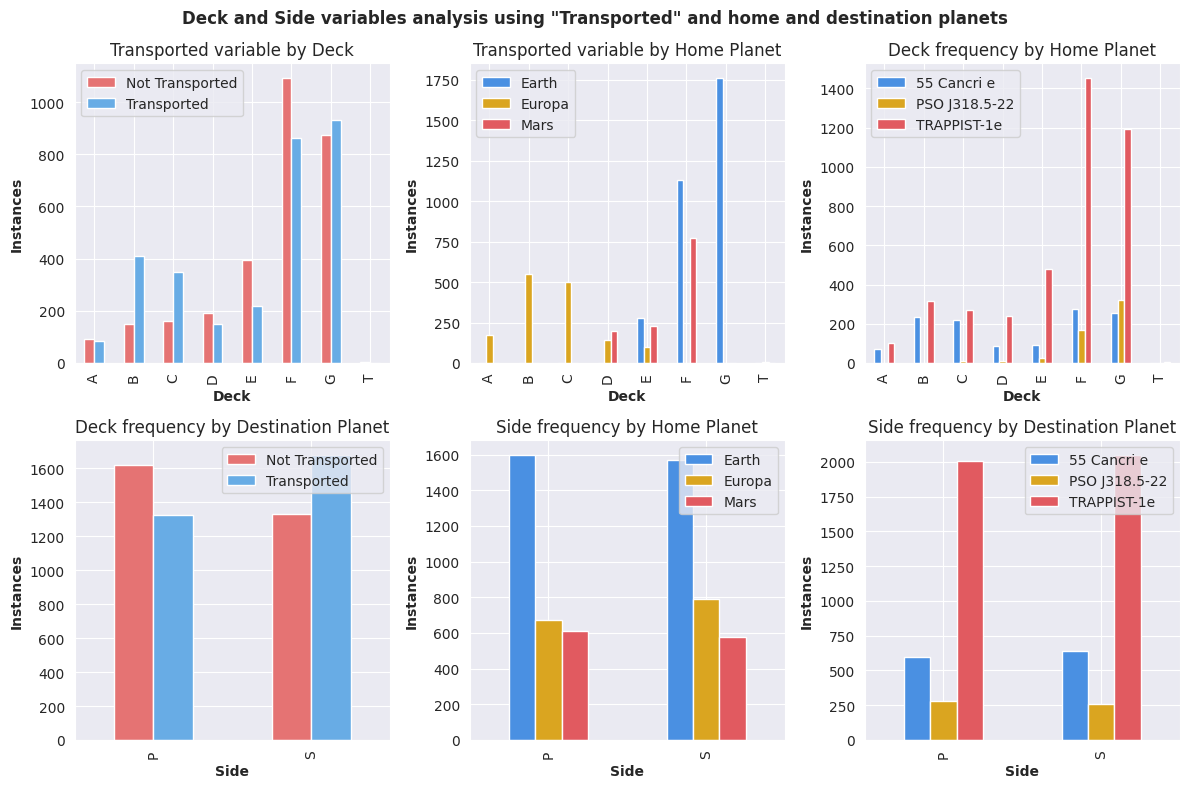

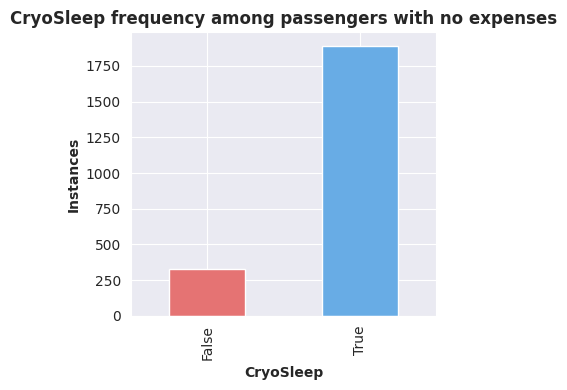

In [ ]:

#visualizamos como queda el dataframe 


OUTLIERS


Un cuartil es un valor que divide un conjunto de datos ordenados en cuatro partes iguales. Se usa en estadística para entender cómo se distribuyen los datos y es clave en herramientas como el boxplot. Hay tres cuartiles principales: Q1, Q2 y Q3.

Los cuartiles:

Q1 (Primer cuartil):
    Es el valor por debajo del cual está el 25% de los datos.
    Si ordenas tus datos de menor a mayor, Q1 es el punto que deja un cuarto de los valores a su izquierda.

Q2 (Segundo cuartil o Mediana):
    Es el valor por debajo del cual está el 50% de los datos.
    Coincide con la mediana, el número que está justo en el medio cuando los datos están ordenados.

Q3 (Tercer cuartil):
    Es el valor por debajo del cual está el 75% de los datos.
    Marca el punto donde tres cuartos de los datos están a su izquierda.


Partes de un Boxplot:

Caja (Box):

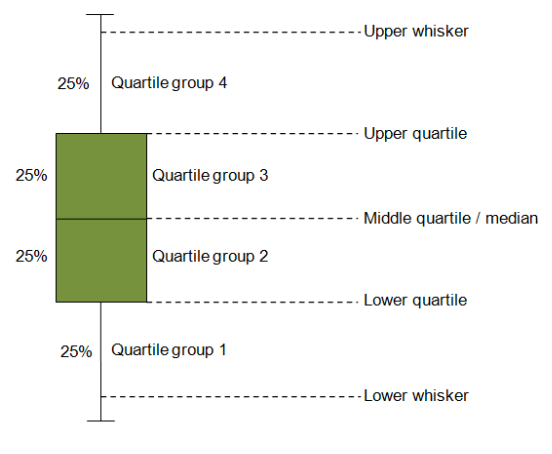

    La caja representa el rango intercuartílico (IQR), que es la distancia entre el primer cuartil (Q1) y el tercer cuartil (Q3).
    Q1 (25%): El valor por debajo del cual está el 25% de los datos.
    Q3 (75%): El valor por debajo del cual está el 75% de los datos.
    La caja muestra el 50% central de los datos (desde Q1 hasta Q3).

Línea dentro de la caja (Mediana):

    Es el segundo cuartil (Q2) o la mediana, el valor que divide los datos en dos mitades iguales (el 50% de los datos está por encima y el 50% por debajo).
    
Bigotes (Whiskers):

    Los bigotes se extienden desde los bordes de la caja (Q1 y Q3) hasta los valores mínimos y máximos que no se consideran outliers.
    Límite inferior del bigote: Q1 - (factor * IQR), donde el factor suele ser 1.5 por defecto, pero es ajustable.
    Límite superior del bigote: Q3 + (factor * IQR).
    Los bigotes muestran el rango de los datos que están dentro de un límite "normal", excluyendo los valores extremos.

Outliers (Valores atípicos):
    Son los puntos que quedan fuera de los bigotes.
    Se consideran outliers los valores que están por debajo de Q1 - (factor * IQR) o por encima de Q3 + (factor * IQR).
    En el gráfico, suelen aparecer como puntos o círculos individuales.

IQR (Rango Intercuartílico):

    Es la longitud de la caja: IQR = Q3 - Q1.
    Representa la dispersión del 50% central de los datos y se usa para calcular los límites de los bigotes y detectar outliers.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo las columnas numéricas del DataFrame
numeric_cols = EDA_train_raw_imputed.select_dtypes(include=['float64']).columns

# Definir el factor de IQR parametrizable (por defecto es 1.5, pero puedes ajustarlo)


# Configurar el tamaño de la figura


# Crear un boxplot para cada variable numérica


# Ajustar el diseño para evitar solapamiento
plt.tight_layout()
plt.show()



## Escalado de variables: interpretación estadística

Cuando se aplica un método como StandardScaler, cada variable se transforma según la siguiente expresión:

$$
x_{scaled} = \frac{x - \mu}{\sigma}
$$

donde:
- $\mu$ es la media de la variable  
- $\sigma$ es la desviación estándar  

Como resultado, la variable transformada tiene:
- media igual a 0  
- desviación estándar igual a 1  

---

## Motivos para aplicar el escalado

### 1. Igualar las escalas de las variables

En muchos conjuntos de datos, las variables pueden tener rangos muy distintos. Por ejemplo:
- Edad: valores entre 0 y 100  
- Ingresos: valores entre 0 y 100000  

Sin escalado, los modelos pueden asignar mayor importancia a las variables con valores más grandes simplemente por su magnitud. El escalado elimina este efecto y sitúa todas las variables en una escala comparable.

---

### 2. Evitar sesgos en el cálculo de distancias

Algunos algoritmos se basan en medidas de distancia, como:
- K-Nearest Neighbors (KNN)  
- K-Means  
- Support Vector Machines (SVM)  

En estos casos, si una variable tiene valores mucho mayores que otra, dominará el cálculo de la distancia. El escalado asegura que todas las variables contribuyan de forma equilibrada.

---

### 3. Mejorar la convergencia en métodos de optimización

Modelos como:
- regresión lineal o logística  
- redes neuronales  

utilizan algoritmos de optimización como el descenso por gradiente. Si las variables no están escaladas, el espacio de optimización puede estar distorsionado, lo que provoca:
- convergencia más lenta  
- trayectorias ineficientes  

El escalado hace que el espacio sea más uniforme y facilita una convergencia más rápida y estable.

---

### 4. Interpretación estadística de los valores

Tras el escalado:
- un valor de 1 indica que la observación está a una desviación estándar por encima de la media  
- un valor de -1 indica que está por debajo de la media  

Esto permite interpretar todas las variables en una misma escala relativa.

---

## Cuándo es necesario aplicar escalado

Es especialmente importante en modelos basados en distancias o en optimización:
- KNN  
- SVM  
- regresión lineal y logística  
- redes neuronales  
- PCA  
- clustering  

En cambio, no es relevante en modelos basados en árboles, como:
- árboles de decisión  
- random forest  
- gradient boosting  

Estos modelos no dependen de distancias ni de la escala de las variables.

---

## Resumen

El escalado permite que todas las variables tengan una distribución comparable, evitando que la magnitud de algunas influya indebidamente en el modelo y mejorando tanto la estabilidad como la eficiencia del aprendizaje.

In [ ]:
#ESCALADO DE VARIABLES NUMÉRICAS Y CODIFICACIÓN ONE HOT DE LAS CATEGÓRICAS

EDA_train_raw_imputed_scaled_oh=EDA_train_raw_imputed.copy()

#nos cargamos la columna cabin_num porque si no genera muchísmas columnas en el onehotencoder
EDA_train_raw_imputed_scaled_oh.drop('Cabin_Num',axis=1,inplace=True)


#get updated numeric an categorical col names
EDA_updated_numeric_columns = list(EDA_train_raw_imputed_scaled_oh.select_dtypes(include=['number']).columns)
print('NUM', EDA_updated_numeric_columns)

EDA_updated_cat_columns = list(EDA_train_raw_imputed_scaled_oh.select_dtypes(include=['object']).columns)
print('CAT', EDA_updated_cat_columns)


# Crear un objeto StandardScaler
scaler = StandardScaler()

# Aplicar el escalado solo a las variables numéricas
EDA_train_raw_imputed_scaled_oh[EDA_updated_numeric_columns] = scaler.fit_transform(EDA_train_raw_imputed_scaled_oh[EDA_updated_numeric_columns])

#aplicar codificaión onehot a las variables categóricas

EDA_train_raw_imputed_scaled_oh = pd.get_dummies(EDA_train_raw_imputed_scaled_oh, columns=EDA_updated_cat_columns, drop_first=True)


In [ ]:
EDA_train_raw_imputed_scaled_oh.head()

In [ ]:
#CORRELACIÓN ENTRE CADA VARIABLE CON EL TARGET



## Introducción a la selección de variables en Machine Learning

### ¿Qué es la selección de variables?

La selección de variables (feature selection) es el proceso mediante el cual se eligen las características más relevantes de un conjunto de datos para construir un modelo de machine learning. Estas características corresponden a las columnas del dataset (por ejemplo, `Age`, `RoomService`, etc.).

Sus principales objetivos son:
- Reducir la complejidad del modelo al trabajar con menos variables.
- Mejorar el rendimiento eliminando ruido o variables irrelevantes.
- Disminuir el coste computacional.

Es importante distinguir este concepto de la **reducción de dimensionalidad**. Mientras que la selección de variables elige un subconjunto de las variables originales, la reducción de dimensionalidad (por ejemplo, mediante PCA) crea nuevas variables a partir de combinaciones de las existentes.

---

### Tipos de métodos de selección de variables

Existen tres grandes categorías: métodos Filter, Wrapper y Embedded.

---

### 1. Métodos Filter (Filtro)

**Definición:**  
Evalúan cada variable de forma independiente utilizando criterios estadísticos, sin necesidad de entrenar un modelo de machine learning.

**Funcionamiento:**  
Se aplican métricas estadísticas para medir la relevancia de cada variable respecto a la variable objetivo. Algunas de las más habituales son:
- Varianza: elimina variables con poca variabilidad.
- Correlación: mide la relación entre variables numéricas.
- Chi-cuadrado: evalúa la relación entre variables categóricas y la variable objetivo.
- ANOVA: analiza la relación entre variables numéricas y una variable objetivo categórica.

**Ejemplos:**
- Eliminar una variable con varianza muy baja (por ejemplo, si casi todos los valores son iguales).
- Detectar variables altamente correlacionadas y considerar eliminar una de ellas (especialmente relevante en modelos lineales por problemas de multicolinealidad).

**Ventajas:**
- Rápidos y computacionalmente eficientes.
- Independientes del modelo utilizado.

**Desventajas:**
- No tienen en cuenta interacciones entre variables.
- Pueden descartar variables que son útiles en combinación con otras.

**Cuándo utilizarlos:**  
Son adecuados como paso inicial para reducir el número de variables antes de aplicar métodos más complejos.

---

### 2. Métodos Wrapper (Envolventes)

**Definición:**  
Utilizan un modelo de machine learning para evaluar distintas combinaciones de variables y seleccionar aquellas que optimizan el rendimiento.

**Funcionamiento:**  
Se entrenan múltiples modelos con distintos subconjuntos de variables y se comparan sus resultados utilizando métricas de evaluación (precisión, error, etc.).

**Ejemplos:**
- Forward Selection: comienza sin variables y añade progresivamente las más relevantes.
- Backward Elimination: comienza con todas las variables y elimina las menos útiles.
- Recursive Feature Elimination (RFE): elimina iterativamente las variables menos importantes según un modelo.

**Ventajas:**
- Tienen en cuenta interacciones entre variables.
- Optimizan directamente el rendimiento del modelo.

**Desventajas:**
- Alto coste computacional.
- Riesgo de sobreajuste si no se utiliza validación cruzada.

**Cuándo utilizarlos:**  
Son útiles cuando se busca maximizar el rendimiento del modelo y se dispone de recursos computacionales suficientes.

---

### 3. Métodos Embedded (Integrados)

**Definición:**  
La selección de variables se realiza de forma automática durante el entrenamiento del modelo.

**Funcionamiento:**  
El propio algoritmo determina la importancia de cada variable como parte de su proceso de aprendizaje.

**Ejemplos:**
- Lasso (regularización L1): reduce a cero los coeficientes de variables irrelevantes, eliminándolas efectivamente del modelo.
- Modelos basados en árboles (Random Forest, Gradient Boosting): proporcionan medidas de importancia de las variables.

**Ventajas:**
- Combinan eficiencia computacional con buen rendimiento.
- Consideran interacciones entre variables.

**Desventajas:**
- Dependen del modelo utilizado.
- Algunas técnicas (como Lasso) pueden no capturar relaciones no lineales.

**Cuándo utilizarlos:**  
Son apropiados cuando ya se ha elegido un modelo concreto y se desea obtener una selección de variables coherente con él.

---

### Comparación entre métodos Filter y Wrapper

- **Filter:** evalúa variables de forma individual mediante estadísticas simples, sin entrenar modelos.
- **Wrapper:** evalúa combinaciones de variables utilizando un modelo de machine learning.

---

### Consideraciones importantes

- La selección de variables debe realizarse únicamente sobre el conjunto de entrenamiento para evitar problemas de *data leakage*.
- No siempre es necesario aplicar selección de variables. Modelos como Random Forest o Gradient Boosting suelen manejar bien un gran número de variables.
- La utilidad de la selección depende del tipo de modelo: es más relevante en modelos lineales o basados en distancias que en modelos basados en árboles.

---

-------------------------------------------------------------------------------------------------------------- 

## Selección de variables: métodos estadísticos y supuestos

La elección del método estadístico depende del tipo de variables (categóricas o numéricas) y de los supuestos que se cumplen.

---

### 1. Variable categórica vs variable categórica

**Test: Chi-cuadrado de independencia**

- Evalúa si existe relación entre dos variables categóricas.
- Supuestos:
  - Observaciones independientes.
  - Frecuencias esperadas suficientemente grandes (habitualmente ≥ 5 por celda).

**Alternativa:**
- Test exacto de Fisher (cuando hay pocas observaciones o frecuencias bajas).

---

### 2. Variable numérica vs variable categórica

**Test: ANOVA (más de dos grupos) o t-test (dos grupos)**

- Evalúa si existen diferencias en la media de la variable numérica entre grupos.

**Supuestos:**
- Normalidad de la variable numérica dentro de cada grupo (ej. test de Shapiro-Wilk).
- Homogeneidad de varianzas (ej. test de Levene o Bartlett).
- Independencia de observaciones.

**Alternativas no paramétricas:**
- Mann-Whitney (dos grupos).
- Kruskal-Wallis (más de dos grupos).

---

### 3. Variable numérica vs variable numérica

**Test: Correlación de Pearson**

- Mide la relación lineal entre dos variables numéricas.

**Supuestos:**
- Relación lineal.
- Normalidad (al menos aproximada).
- Ausencia de outliers significativos.

**Alternativa:**
- Correlación de Spearman (no requiere normalidad, basada en rangos, detecta relaciones monótonas).

---

### 4. Resumen rápido

- Categórica vs categórica → Chi-cuadrado (o Fisher si muestras pequeñas).
- Numérica vs categórica → t-test / ANOVA (o Mann-Whitney / Kruskal-Wallis si no se cumplen supuestos).
- Numérica vs numérica → Pearson (o Spearman si no se cumplen supuestos).

1. Método filter:

1.1 Correlación de Pearson

-   Qué mide: Relación lineal entre dos variables numéricas (valores de -1 a 1).

-   Cuándo usarla: Para variables numéricas (Age, RoomService, FoodCourt, ShoppingMall, Spa, VRDeck, Gastos) y un objetivo numérico. Como Transported es booleano, lo conviertes a 0/1.

    Interpretación:
    -   Cerca de 0: Baja relación → descartar.
    -   Cerca de 1 o -1: Alta relación → mantener.

-   Ejemplo: Correlación entre Spa y Transported. Si es -0.4, Spa influye negativamente (a más gasto en Spa, menos probabilidad de ser transportado).

-   Limitación: Solo captura relaciones lineales.




In [ ]:
#obtener el corr de pearson de las variables con la clase . Ojo lo que pone en la celda de arriba!



Interpretación:



1.2. Prueba Chi-cuadrado (Chi²)

-   Qué mide: Relación entre variables categóricas y un objetivo categórico.

-   Cuándo usarla: Para variables categóricas (HomePlanet, Destination, VIP, Cabin_Deck, etc.) y Transported.

-   Interpretación:

    -   Valor alto y p-valor < 0.05: Relación significativa → mantener.
    -   Valor bajo o p-valor > 0.05: Sin relación → descartar.

    Ejemplo: Si HomePlanet (Earth, Mars, Europa) tiene un Chi² alto con Transported, es relevante.




In [ ]:
EDA_train_raw_imputed.dtypes

In [ ]:
#aplicar chi2

## Análisis estadístico: p-valor, hipótesis nula y nivel de significancia

### ¿Qué es el p-valor?

El p-valor es una medida estadística que permite evaluar si los resultados observados en los datos son compatibles con la hipótesis nula (H0), o si es poco probable que se deban al azar.

En términos más formales:

> El p-valor representa la probabilidad de observar unos resultados iguales o más extremos que los obtenidos, asumiendo que la hipótesis nula es cierta.

Interpretación práctica:

- p-valor pequeño (por ejemplo, < 0.05): indica que los datos observados son poco probables bajo la hipótesis nula → hay evidencia en contra de H0.
- p-valor grande (por ejemplo, > 0.05): los datos son compatibles con H0 → no hay evidencia suficiente para rechazarla.

---

### ¿Qué es la hipótesis nula (H0)?

La hipótesis nula (H0) es la suposición inicial de que **no existe relación o efecto** entre las variables.

Ejemplo:
- H0: "HomePlanet no influye en Transported"

Es el punto de partida del contraste estadístico. El objetivo del análisis es evaluar si hay suficiente evidencia en los datos para rechazar esta hipótesis.

---

### Nivel de significancia (α) y nivel de confianza

Para tomar decisiones se fija un umbral llamado **nivel de significancia**, denotado como α (alpha).

- Valor típico: α = 0.05

Este valor representa la probabilidad máxima de cometer un **error tipo I**, es decir, rechazar la hipótesis nula cuando en realidad es cierta.

Relación con el nivel de confianza:

- Nivel de confianza = 1 - α
- Si α = 0.05 → nivel de confianza = 95%

---

### Regla de decisión

- Si p-valor < α → se rechaza H0  
- Si p-valor ≥ α → no se rechaza H0  

Importante:
- "No rechazar H0" no significa que sea verdadera, sino que no hay evidencia suficiente en su contra.

---

### Ejemplos

**Para HomePlanet_Europa (p ≈ 0.000):**

- H0: "Venir de Europa no afecta ser transportado"
- El p-valor es extremadamente pequeño → muy improbable bajo H0
- Se rechaza H0 → existe evidencia de que la variable influye en `Transported`

---

**Para Cabin_Deck_A (p = 0.862):**

- H0: "La cubierta A no afecta ser transportado"
- El p-valor es alto → compatible con H0
- No se rechaza H0 → no hay evidencia de efecto

---

### Conclusión (selección de variables)

Basado en el contraste estadístico:

- **Mantener**:  
  HomePlanet_Earth, HomePlanet_Europa, HomePlanet_Mars,  
  Cabin_Deck_B, Cabin_Deck_C, Cabin_Deck_D, Cabin_Deck_E, Cabin_Deck_F  

- **Descartar**:  
  Cabin_Deck_A, Cabin_Deck_G, Cabin_Deck_T  

---

### Nota importante

El p-valor no mide la magnitud del efecto ni la importancia práctica de una variable, sino únicamente la evidencia estadística contra la hipótesis nula. Por tanto, debe complementarse con otras métricas en el contexto de machine learning.

1.3 Ganancia de Información (Mutual Information)

Qué mide: Cuánta información aporta una variable (numérica o categórica) sobre el objetivo, basada en la reducción de entropía.

En castellano: La ganancia de información mide cuánto "sabe" una variable (como Age o HomePlanet) sobre otra (como Transported). Si saber el valor de esa variable reduce la incertidumbre o "desorden" (entropía) sobre Transported, entonces aporta información útil. Hemos dividido los datos por Cabin_Deck (A, B, C, etc.). Si en la cubierta B casi todos son Transported = True y en la A casi todos son False, saber en qué cubierta está alguien te da una pista clara sobre si fue transportado o no. Eso es "alta ganancia de información". Reduce la incertidumbre. Sin saber la cubierta, no tendríamos ni idea; con la cubierta, adivinaremos mejor.

Entropía: Es como medir qué tan "mezclados" o impredecibles son los datos. Si Transported es 50% True y 50% False, hay mucho desorden (alta entropía). Si una variable como Cabin_Deck ayuda a separar esos True y False, la entropía baja y eso es bueno. Menor desorden -> Menor incertidumbre

Cuándo usarla: Para cualquier tipo de variable (numéricas como Age o categóricas como HomePlanet) y un objetivo categórico/binario como Transported.

Puedemos usar esta técnica tanto si las variables son números (como Age o Spa) como si son categorías (como HomePlanet o Cabin_Deck), y funciona bien cuando el objetivo es algo como Transported (True/False, o sea, binario).

Por qué importa: No necesitas preocuparte por el tipo de dato, es súper versátil.

interpretación:

-   0: Sin relación → descartar.
-   Mayor que 0: Aporta información → mantener (valores más altos son mejores).


La ganancia de información mutua (MI) es invariante al escalado de las variables numéricas porque se basa en las distribuciones de probabilidad, no en los valores absolutos.

--------

RESUMEN:  si una variable reduce el "desorden" (o entropía) en la variable objetivo, es útil. Si no cambia nada, no aporta información. Y lo mejor es que esto funciona tanto con variables numéricas como categóricas, y no le afecta si escalas o transformas tus variables, ya que se basa en las probabilidades de los valores, no en los números exactos.

In [ ]:
#aplicar GI

Análisis:



2. MÉTODOS WRAPPER

2.1.RFE

-   RFE significa "Eliminación Recursiva de Características".
-   Es un método Wrapper porque "envuelve" un modelo de machine learning (como regresión logística o un árbol) para decidir qué variables son más importantes.
-   Cómo funciona:
    -   Empieza con todas las variables.
    -   Entrena el modelo y mide la importancia de cada variable.
    -   Elimina la menos importante.
    -   Repite hasta quedarte con el número de variables que quieres.
    -   Por qué es popular: Es automático, usa el modelo para evaluar combinaciones y encuentra las variables que realmente mejoran la predicción.

-   Podemos seleccionar el modelo que queramos, pero debemos tener en cuenta si existe una relación lineal o no entre las variables y la clase. Por ejemplo, si no es lineal no se puede usar logistic regression, dado que solo nos vale para relaciones lineales (aclaración: que tenga una función de activación al final para obtener la p. de una clase, no significa que sea un método válido para un caso donde no hay una relación no lineal entre las variables).

-   Lineal: El efecto de una variable sobre Transported es constante y sigue una línea recta. Ejemplo: a más Spa, la probabilidad de Transported sube/baja siempre igual.
-   No lineal: El efecto cambia según el valor de la variable o combina con otras. Ejemplo: Spa bajo y alto afectan Transported, pero valores medios no.

Podemos usar RandomForest, que maneja tanto relaciones lineales como no lineales, funciona bien con variables numéricas y categóricas. Vaya, un "todoterreno". Es recomendable escalar las numéricas para que RFE sea más equilibrado al comparar numéricas con las categoricas (onehot), sobre todo si hay variaciones grandes.


In [ ]:
#Aplicar RFE y decidme qué variables serían las que permanecen

Reducción de dimensionalidad - PCA (Principal component Analisis)

PCA (Análisis de Componentes Principales) es una técnica de reducción de dimensionalidad. En lugar de seleccionar variables existentes (como hace Feature Selection), PCA crea **nuevas variables (llamadas componentes principales) que son combinaciones lineales de las originales**, maximizando la varianza explicada. Estos componentes son combinaciones lineales de las variables originales y están diseñados para capturar la mayor cantidad posible de varianza en los datos.

Varianza: Es una medida de cuánto se "dispersan" o varían tus datos. Si tienes mucha varianza, tus datos tienen mucha información (cambios, patrones). 
Si tienes poca varianza, tus datos son más uniformes (menos información).
Varianza explicada: Es la cantidad de varianza total de tus datos que un componente (o un grupo de componentes) puede "explicar" o representar.

**Interesa tener el máximo de varianza explicada por las componentes principales**

Cómo funciona (en pasos simples):

-   Estandarizar los datos:
-   Las variables deben estar en la misma escala (ej. restar la media y dividir por la desviación estándar), porque PCA es sensible a las magnitudes.
-   Calcular componentes principales:
    -   PCA encuentra nuevas "direcciones" (componentes) en los datos que explican la mayor cantidad de varianza.
    -   El primer componente (PC1) captura la mayor varianza, el segundo (PC2) la segunda mayor, y así sucesivamente.
    -   Ejemplo: Si tienes Age y Spa, PC1 podría ser algo como 0.7⋅𝐴𝑔𝑒+0.3⋅𝑆𝑝𝑎   -> 1 única componente.

Reducir dimensionalidad:

Eliges cuántos componentes quieres (ej. 2 o 3) para quedarte con los que explican la mayor parte de la varianza (ej. 95%).

Transformar los datos:

-   Tus datos originales (ej. Age, Spa, HomePlanet_Earth, etc.) se convierten en nuevos valores en los componentes (PC1, PC2, etc.). por qué? En lugar de usar las 13 variables originales, podrías usar solo 2 o 3 componentes que expliquen, digamos, el 90% de la varianza.

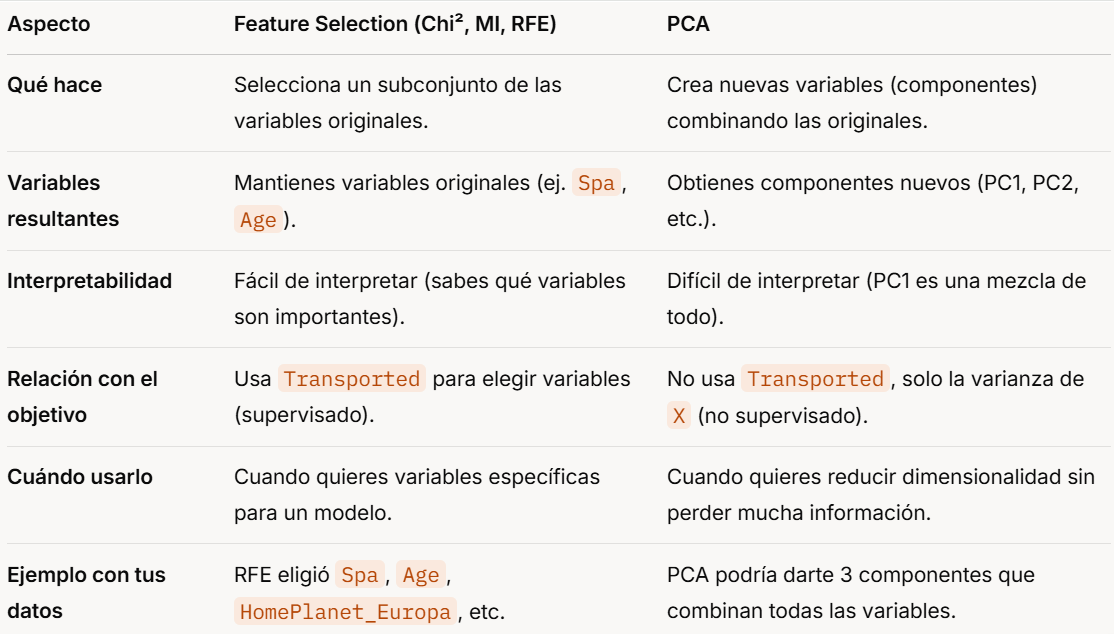

2 approaches distintos, para dejar claro que NO es lo mismo:

-   Feature Selection: "Voy a elegir las mejores variables (ej. Spa, Age) basándome en su relación con Transported".

-   PCA: "Voy a crear nuevas variables (PC1, PC2) que resuman toda la información de mis datos, sin mirar Transported".

En resumen:

Cuando decimos que queremos que los componentes expliquen más del 95% de la varianza, significa que queremos conservar casi toda la información de los datos originales, pero usando menos variables (componentes).

Por qué 95%: 

-   Es un umbral común (puede ser 90%, 99%, etc.) que asegura que no pierdes demasiada información al reducir dimensionalidad.

En PCA:

-   Si los datos originales tienen 13 variables por ejemplo, PCA podría reducirlas a 4 componentes que expliquen el 95% de la varianza.

Esas 4 componentes "resumen" casi toda la información de las 13 variables originales, con la ventaja de ser más eficientes en el entrenamiento.

**En la práctica, al crear nuevas variables como combinación lineal de varias, se pierde un poco el sentido de lo que es cada una y a veees es complicado analizar el resultado**

In [ ]:

EDA_train_raw_imputed.dtypes

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Preprocesar los datos
# Separar la variable objetivo
X = EDA_train_raw_imputed.drop(columns=['Transported'])
y = EDA_train_raw_imputed['Transported'].astype(int)

# Convertir booleanas a 0/1
X['Acompañado'] = X['Acompañado'].astype(int)

# Identificar columnas categóricas y numéricas
categorical_cols = ['HomePlanet', 'Destination', 'VIP', 'Cabin_Deck', 'Cabin_Side', 'Mod_CryoSleep']
numeric_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Gastos']

# Manejar Cabin_Num (puede tener muchos valores únicos, lo excluimos por ahora)
X = X.drop(columns=['Cabin_Num'])

# Convertir categóricas a dummies (one-hot encoding)
X = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

# 2. Estandarizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Aplicar PCA
# Usar todos los componentes para analizar la varianza
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Varianza explicada
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# 4. Elegir número de componentes con el criterio del 95%
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Número de componentes para 95% de varianza: {n_components_95}")

# 5. Visualizar la varianza explicada (criterio del codo)
plt.figure(figsize=(12, 5))

# Gráfico 1: Varianza explicada por cada componente
plt.subplot(1, 2, 1)
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', label='Varianza explicada')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada por componente')
plt.title('Varianza explicada por cada componente')
plt.grid(True)

# Gráfico 2: Varianza explicada acumulada
plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', label='Varianza acumulada')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% varianza')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('Varianza explicada acumulada')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 6. Aplicar PCA con el número de componentes elegido (95% varianza)
pca_95 = PCA(n_components=n_components_95)
X_pca_95 = pca_95.fit_transform(X_scaled)

# 7. Mostrar los pesos de las variables en cada componente
components_df = pd.DataFrame(
    pca_95.components_,
    columns=X.columns,
    index=[f'PC{i+1}' for i in range(n_components_95)]
)
print("\nPesos de las variables en cada componente:")
print(components_df)

Análisis:

Qué significan los pesos?



por qué hay 25 componentes después de preprocesar el DataFrame?



El criterio del codo busca el punto donde la curva deja de subir rápidamente y se aplana, indicando que añadir más componentes aporta poca ganancia en varianza explicada.

Y con cuántes PC me quedo ahora? Dos criterios:

-   Criterio del codo -> cuantas componentes quedan?
-   Criterio del 95%  -> cuantas componentes quedan?

Recomiendas PCA en este caso? 
